In [5]:
import duckdb
import pandas as pd
from pathlib import Path

In [6]:
project_root = Path("/Users/saraneff/Desktop/taxi-project")

cleaned_dir = project_root / "data" / "cleaned"
raw_dir = project_root / "data" / "raw"

con = duckdb.connect()

In [7]:
trips = con.execute(f"""
SELECT *
FROM read_parquet('{cleaned_dir.as_posix()}/yellow_tripdata_2024-*.parquet')
LIMIT 10
""").fetchdf()

trips

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,2,2024-01-01 00:57:55,2024-01-01 01:17:43,1,1.72,1,N,186,79,2,17.7,1.0,0.5,0.00,0.0,1.0,22.70,2.5,0.00
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1,1.80,1,N,140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.00
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1,4.70,1,N,236,79,1,23.3,3.5,0.5,3.00,0.0,1.0,31.30,2.5,0.00
3,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1,1.40,1,N,79,211,1,10.0,3.5,0.5,2.00,0.0,1.0,17.00,2.5,0.00
4,1,2024-01-01 00:46:51,2024-01-01 00:52:57,1,0.80,1,N,211,148,1,7.9,3.5,0.5,3.20,0.0,1.0,16.10,2.5,0.00
5,1,2024-01-01 00:54:08,2024-01-01 01:26:31,1,4.70,1,N,148,141,1,29.6,3.5,0.5,6.90,0.0,1.0,41.50,2.5,0.00
6,2,2024-01-01 00:49:44,2024-01-01 01:15:47,2,10.82,1,N,138,181,1,45.7,6.0,0.5,10.00,0.0,1.0,64.95,0.0,1.75
7,1,2024-01-01 00:30:40,2024-01-01 00:58:40,0,3.00,1,N,246,231,2,25.4,3.5,0.5,0.00,0.0,1.0,30.40,2.5,0.00
8,2,2024-01-01 00:26:01,2024-01-01 00:54:12,1,5.44,1,N,161,261,2,31.0,1.0,0.5,0.00,0.0,1.0,36.00,2.5,0.00
9,2,2024-01-01 00:28:08,2024-01-01 00:29:16,1,0.04,1,N,113,113,2,3.0,1.0,0.5,0.00,0.0,1.0,8.00,2.5,0.00


In [8]:
zones = con.execute(f"""
SELECT *
FROM read_csv_auto('{raw_dir.as_posix()}/taxi_zone_lookup.csv')
""").fetchdf()

zones.head()

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


In [ ]:
# how many trips started in each zone
trip_counts = con.execute(f"""
SELECT
    t.PULocationID,
    z.Borough,
    z.Zone,
    COUNT(*) AS trips
FROM read_parquet('{cleaned_dir.as_posix()}/yellow_tripdata_2024-*.parquet') t
LEFT JOIN read_csv_auto('{raw_dir.as_posix()}/taxi_zone_lookup.csv') z
    ON t.PULocationID = z.LocationID
GROUP BY
    t.PULocationID,
    z.Borough,
    z.Zone
ORDER BY trips DESC
""").fetchdf()

trip_counts.head(20)

,PULocationID,Borough,Zone,trips
0,237,Manhattan,Upper East Side South,1871636
1,132,Queens,JFK Airport,1870532
2,161,Manhattan,Midtown Center,1861418
3,236,Manhattan,Upper East Side North,1691277
4,162,Manhattan,Midtown East,1381338
5,230,Manhattan,Times Sq/Theatre District,1338236
6,186,Manhattan,Penn Station/Madison Sq West,1324023
7,142,Manhattan,Lincoln Square East,1281090
8,138,Queens,LaGuardia Airport,1260772
9,170,Manhattan,Murray Hill,1140026


In [ ]:
# total number of trips in the cleaned data
con.execute(f"""
SELECT COUNT(*)
FROM read_parquet('{cleaned_dir.as_posix()}/yellow_tripdata_2024-*.parquet')
""").fetchall()

[(39694569,)]

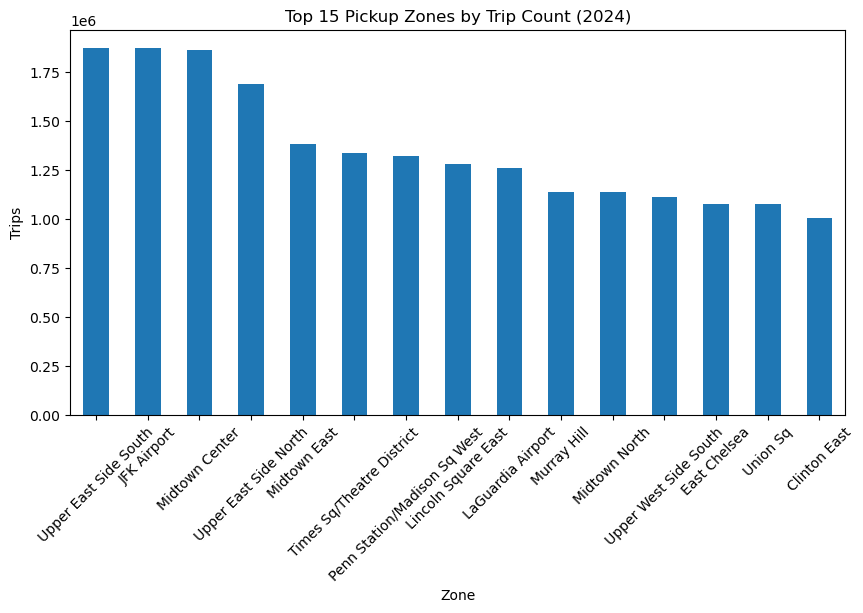

In [11]:
# plot the busiest zones
import matplotlib.pyplot as plt

trip_counts.head(15).plot(
    x="Zone",
    y="trips",
    kind="bar",
    figsize=(10,5),
    legend=False
)

plt.title("Top 15 Pickup Zones by Trip Count (2024)")
plt.ylabel("Trips")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# check the minimum fare amount in the cleaned data
con.execute(f"""
SELECT MIN(fare_amount) AS min_fare
FROM read_parquet('{cleaned_dir.as_posix()}/yellow_tripdata_2024-*.parquet')
""").fetchdf()

,min_fare
0,0.0


In [13]:
# check the minimum trip distance in the cleaned data
con.execute(f"""
SELECT MIN(trip_distance) AS min_distance
FROM read_parquet('{cleaned_dir.as_posix()}/yellow_tripdata_2024-*.parquet')
""").fetchdf()

,min_distance
0,0.01


In [14]:
# check the max trip duration in the cleaned data
con.execute(f"""
SELECT
MAX(tpep_dropoff_datetime - tpep_pickup_datetime) AS max_duration
FROM read_parquet('{cleaned_dir.as_posix()}/yellow_tripdata_2024-*.parquet')
""").fetchdf()

,max_duration
0,0 days 05:59:57


In [15]:
# check how many trips have positive revenue

con.execute(f"""
SELECT COUNT(*) AS positive_revenue_trips
FROM read_parquet('{cleaned_dir.as_posix()}/yellow_tripdata_2024-*.parquet')
WHERE total_amount > 0
""").fetchdf()

,positive_revenue_trips
0,39690787


In [16]:
# distribution of trip durations
con.execute(f"""
SELECT
AVG(tpep_dropoff_datetime - tpep_pickup_datetime) AS avg_trip_time,
MAX(tpep_dropoff_datetime - tpep_pickup_datetime) AS max_trip_time
FROM read_parquet('{cleaned_dir.as_posix()}/yellow_tripdata_2024-*.parquet')
""").fetchdf()

,avg_trip_time,max_trip_time
0,0 days 00:17:27.715016,0 days 05:59:57


In [17]:
# average revenue per trip
con.execute(f"""
SELECT
AVG(total_amount) AS avg_revenue_per_trip
FROM read_parquet('{cleaned_dir.as_posix()}/yellow_tripdata_2024-*.parquet')
""").fetchdf()

,avg_revenue_per_trip
0,28.640974


In [ ]:
# number of trips originating in each zone during morning hours
# filters morning pickups between 6am and 9am, groups by pickup location, 
# joins the zone lookup, and counts the number of trips for each zone

morning_trip_counts = con.execute(f"""
SELECT
    t.PULocationID,
    z.Borough,
    z.Zone,
    COUNT(*) AS morning_trips
FROM read_parquet('{cleaned_dir.as_posix()}/yellow_tripdata_2024-*.parquet') t
LEFT JOIN read_csv_auto('{raw_dir.as_posix()}/taxi_zone_lookup.csv') z
    ON t.PULocationID = z.LocationID
WHERE
    EXTRACT(hour FROM tpep_pickup_datetime) BETWEEN 6 AND 9
GROUP BY
    t.PULocationID,
    z.Borough,
    z.Zone
ORDER BY morning_trips DESC
""").fetchdf()

morning_trip_counts.head(20)

,PULocationID,Borough,Zone,morning_trips
0,236,Manhattan,Upper East Side North,292000
1,186,Manhattan,Penn Station/Madison Sq West,221153
2,237,Manhattan,Upper East Side South,217404
3,132,Queens,JFK Airport,193693
4,162,Manhattan,Midtown East,174937
5,239,Manhattan,Upper West Side South,166445
6,238,Manhattan,Upper West Side North,152232
7,262,Manhattan,Yorkville East,150143
8,141,Manhattan,Lenox Hill West,142085
9,170,Manhattan,Murray Hill,141474


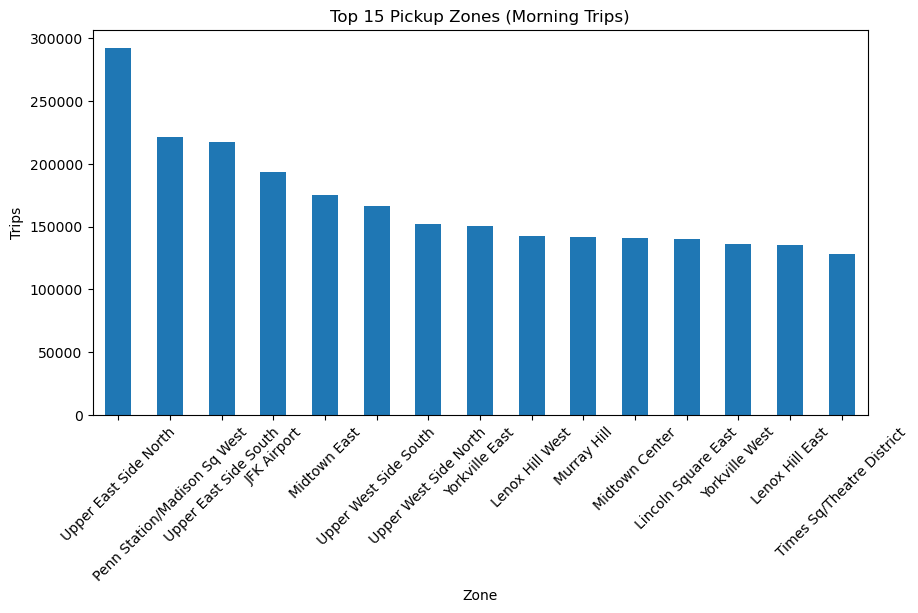

In [20]:
import matplotlib.pyplot as plt

morning_trip_counts.head(15).plot(
    x="Zone",
    y="morning_trips",
    kind="bar",
    figsize=(10,5),
    legend=False
)

plt.title("Top 15 Pickup Zones (Morning Trips)")
plt.ylabel("Trips")
plt.xticks(rotation=45)
plt.show()

In [37]:
# calculate total revenue and revenue per hour for each zone during morning hours
# restricts to morning trips
# computes trip duration in hours
# computes revenue per hour by dividing total revenue by total hours
# this gives passenger revenue per occupied driving hour
# removes small zones with fewer than 100 morning trips to focus on more significant areas

zone_earnings_morning = con.execute(f"""
SELECT
    t.PULocationID,
    z.Borough,
    z.Zone,
    COUNT(*) AS trips,

    SUM(total_amount) AS total_revenue,

    -- compute revenue per occupied hour
    SUM(
        EXTRACT(EPOCH FROM (tpep_dropoff_datetime - tpep_pickup_datetime)) / 3600
    ) AS total_hours,

    SUM(total_amount) /
    SUM(EXTRACT(EPOCH FROM (tpep_dropoff_datetime - tpep_pickup_datetime)) / 3600)
    AS revenue_per_hour

FROM read_parquet('{cleaned_dir.as_posix()}/yellow_tripdata_2024-*.parquet') t

LEFT JOIN read_csv_auto('{raw_dir.as_posix()}/taxi_zone_lookup.csv') z
    ON t.PULocationID = z.LocationID

WHERE
    -- restrict to morning pickups
    EXTRACT(hour FROM tpep_pickup_datetime) BETWEEN 6 AND 9
    AND total_amount > 0

GROUP BY
    t.PULocationID,
    z.Borough,
    z.Zone

HAVING COUNT(*) >= 2000
-- can adjust this threshold to focus on more or fewer zones

ORDER BY revenue_per_hour DESC
""").fetchdf()

zone_earnings_morning.head(20)

,PULocationID,Borough,Zone,trips,total_revenue,total_hours,revenue_per_hour
0,145,Queens,Long Island City/Hunters Point,3189,1.479001e+05,1058.985278,139.662112
1,195,Brooklyn,Red Hook,3983,2.622031e+05,2143.818889,122.306572
2,138,Queens,LaGuardia Airport,109053,7.844667e+06,66708.267500,117.596619
3,230,Manhattan,Times Sq/Theatre District,127776,4.449445e+06,38308.960278,116.146330
4,216,Queens,South Ozone Park,2882,1.591393e+05,1372.124444,115.980238
5,233,Manhattan,UN/Turtle Bay South,66215,1.689505e+06,14908.695833,113.323471
6,70,Queens,East Elmhurst,13742,9.449049e+05,8355.945000,113.081757
7,262,Manhattan,Yorkville East,150125,3.360408e+06,29937.444722,112.247643
8,163,Manhattan,Midtown North,93319,2.613978e+06,23299.165000,112.191925
9,164,Manhattan,Midtown South,77174,1.892543e+06,16898.872500,111.992239


In [38]:
# highest revenue per hour zones during morning hours
zone_earnings_morning.sort_values("revenue_per_hour", ascending=False).head(20)

,PULocationID,Borough,Zone,trips,total_revenue,total_hours,revenue_per_hour
0,145,Queens,Long Island City/Hunters Point,3189,1.479001e+05,1058.985278,139.662112
1,195,Brooklyn,Red Hook,3983,2.622031e+05,2143.818889,122.306572
2,138,Queens,LaGuardia Airport,109053,7.844667e+06,66708.267500,117.596619
3,230,Manhattan,Times Sq/Theatre District,127776,4.449445e+06,38308.960278,116.146330
4,216,Queens,South Ozone Park,2882,1.591393e+05,1372.124444,115.980238
5,233,Manhattan,UN/Turtle Bay South,66215,1.689505e+06,14908.695833,113.323471
6,70,Queens,East Elmhurst,13742,9.449049e+05,8355.945000,113.081757
7,262,Manhattan,Yorkville East,150125,3.360408e+06,29937.444722,112.247643
8,163,Manhattan,Midtown North,93319,2.613978e+06,23299.165000,112.191925
9,164,Manhattan,Midtown South,77174,1.892543e+06,16898.872500,111.992239


In [39]:
# highest trip volume zones during morning hours
zone_earnings_morning.sort_values("trips", ascending=False).head(20)

,PULocationID,Borough,Zone,trips,total_revenue,total_hours,revenue_per_hour
14,236,Manhattan,Upper East Side North,291979,6.014206e+06,55431.974722,108.497051
54,186,Manhattan,Penn Station/Madison Sq West,221146,4.696166e+06,49639.395833,94.605618
15,237,Manhattan,Upper East Side South,217382,4.209363e+06,39096.313611,107.666492
17,132,Queens,JFK Airport,193665,1.520607e+07,141975.385556,107.103578
22,162,Manhattan,Midtown East,174924,4.044211e+06,38165.316389,105.965603
23,239,Manhattan,Upper West Side South,166436,3.815191e+06,36053.831111,105.819296
33,238,Manhattan,Upper West Side North,152222,3.464067e+06,33415.105000,103.667706
7,262,Manhattan,Yorkville East,150125,3.360408e+06,29937.444722,112.247643
28,141,Manhattan,Lenox Hill West,142073,2.951705e+06,28161.751389,104.812543
21,170,Manhattan,Murray Hill,141464,3.185835e+06,30052.727500,106.008182


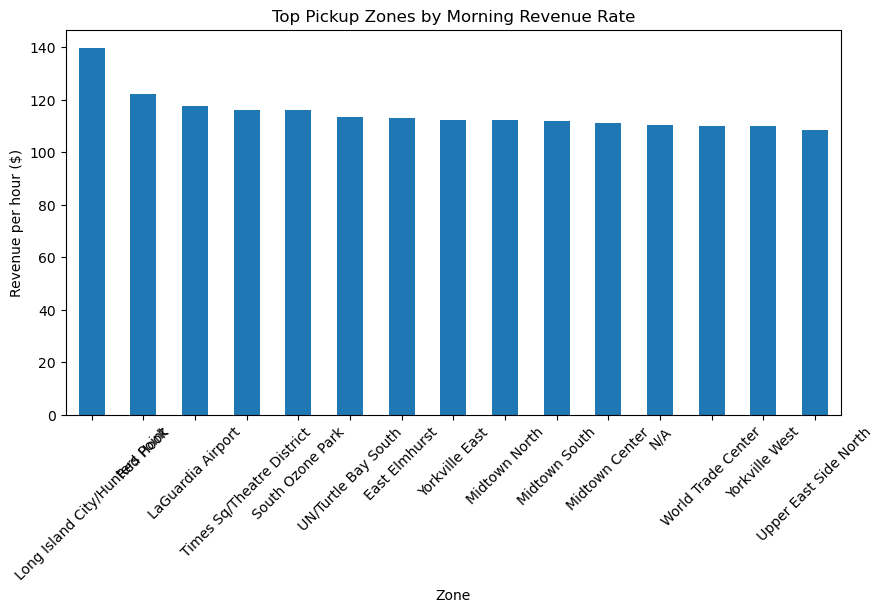

In [40]:
# plot the top zones by revenue/hour

import matplotlib.pyplot as plt

zone_earnings_morning.head(15).plot(
    x="Zone",
    y="revenue_per_hour",
    kind="bar",
    figsize=(10,5),
    legend=False
)

plt.ylabel("Revenue per hour ($)")
plt.title("Top Pickup Zones by Morning Revenue Rate")
plt.xticks(rotation=45)
plt.show()

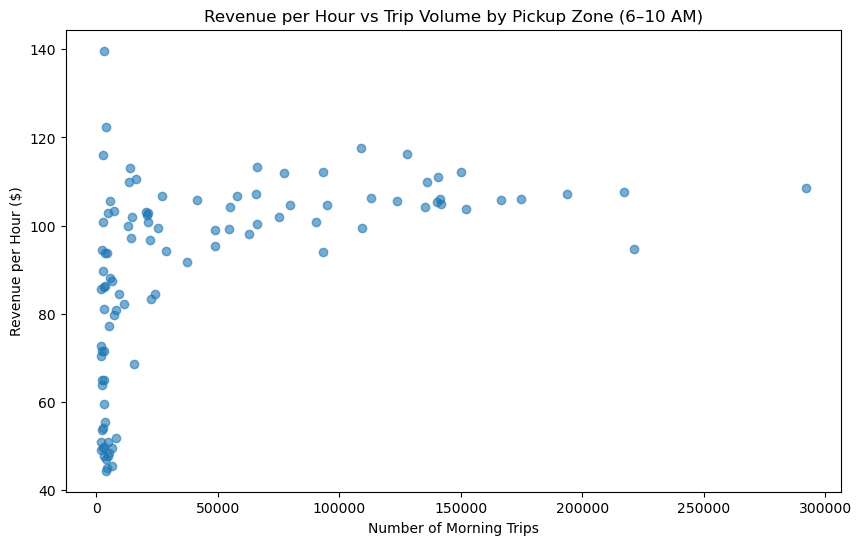

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    zone_earnings_morning["trips"],
    zone_earnings_morning["revenue_per_hour"],
    alpha=0.6
)

plt.xlabel("Number of Morning Trips")
plt.ylabel("Revenue per Hour ($)")
plt.title("Revenue per Hour vs Trip Volume by Pickup Zone (6–10 AM)")

plt.show()

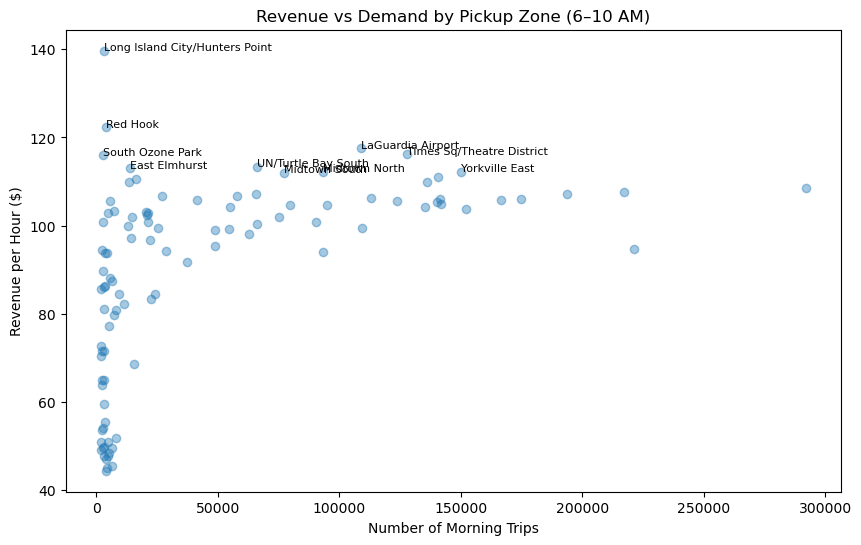

In [42]:
top_zones = zone_earnings_morning.nlargest(10, "revenue_per_hour")

plt.figure(figsize=(10,6))

plt.scatter(
    zone_earnings_morning["trips"],
    zone_earnings_morning["revenue_per_hour"],
    alpha=0.4
)

# label the top zones
for _, row in top_zones.iterrows():
    plt.text(
        row["trips"],
        row["revenue_per_hour"],
        row["Zone"],
        fontsize=8
    )

plt.xlabel("Number of Morning Trips")
plt.ylabel("Revenue per Hour ($)")
plt.title("Revenue vs Demand by Pickup Zone (6–10 AM)")

plt.show()

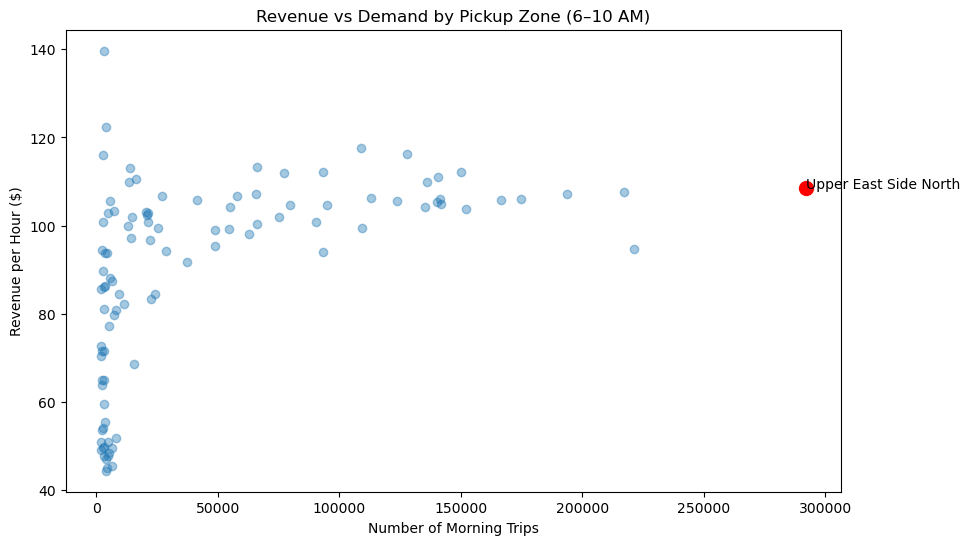

In [43]:
max_zone = zone_earnings_morning.loc[
    zone_earnings_morning["trips"].idxmax()
]

plt.figure(figsize=(10,6))

plt.scatter(
    zone_earnings_morning["trips"],
    zone_earnings_morning["revenue_per_hour"],
    alpha=0.4
)

plt.scatter(
    max_zone["trips"],
    max_zone["revenue_per_hour"],
    color="red",
    s=100
)

plt.text(
    max_zone["trips"],
    max_zone["revenue_per_hour"],
    max_zone["Zone"],
)

plt.xlabel("Number of Morning Trips")
plt.ylabel("Revenue per Hour ($)")
plt.title("Revenue vs Demand by Pickup Zone (6–10 AM)")

plt.show()

In [ ]:
# now we are using a combined earnings index
# that accounts for both revenue per hour and trip volume
# to identify zones that are strong performers on both dimensions, 
# rather than just one or the other. This can help highlight zones that
# are not only high-revenue but also have enough demand to be attractive for drivers.

# how the earnings index is calculated:
# earnings_index = revenue_per_hour * (trips / 4)
# assumptions used
# observed trips represent arrival rate of passengers
# average trip duration is consistent across zones
# idle time is inversely related to trip frequency
# drivers pick up passengers where they drop off
# occupied time approximates working time
# tips are included in total_amount and reflect passenger willingness to pay
# morning pickups approximate shift starts
# historical patterns represent future conditions

zone_earnings_morning = con.execute(f"""
SELECT
    t.PULocationID,
    z.Borough,
    z.Zone,

    COUNT(*) AS trips,

    -- revenue per occupied hour
    SUM(total_amount) /
    SUM(EXTRACT(EPOCH FROM (tpep_dropoff_datetime - tpep_pickup_datetime)) / 3600)
    AS revenue_per_hour,

    -- demand intensity
    -- divide by 4 because we are looking at a 4-hour morning window (6am-10am)
    COUNT(*) / 4.0 AS trips_per_hour,

    -- combined earnings index
    (
        SUM(total_amount) /
        SUM(EXTRACT(EPOCH FROM (tpep_dropoff_datetime - tpep_pickup_datetime)) / 3600)
    ) * (COUNT(*) / 4.0)
    AS earnings_index

FROM read_parquet('{cleaned_dir.as_posix()}/yellow_tripdata_2024-*.parquet') t

LEFT JOIN read_csv_auto('{raw_dir.as_posix()}/taxi_zone_lookup.csv') z
    ON t.PULocationID = z.LocationID

WHERE
    EXTRACT(hour FROM tpep_pickup_datetime) BETWEEN 6 AND 9
    AND total_amount > 0
    AND z.Borough != 'EWR'

GROUP BY
    t.PULocationID,
    z.Borough,
    z.Zone

HAVING COUNT(*) >= 1000

ORDER BY earnings_index DESC
""").fetchdf()

In [47]:
# load taxi zone shapefile

import geopandas as gpd

zones_map = gpd.read_file("../data/raw/taxi_zones/taxi_zones.shp")

zones_map.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


In [48]:
# merge earnings data with zone shapefile for mapping
map_data = zones_map.merge(
    zone_earnings_morning,
    left_on="LocationID",
    right_on="PULocationID",
    how="left"
)

map_data.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,PULocationID,Borough,Zone,trips,revenue_per_hour,trips_per_hour,earnings_index
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20...",4.0,Manhattan,Alphabet City,9562.0,84.469383,2390.5,201924.059634
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144...",NaN,NaN,NaN,NaN,NaN,NaN,NaN


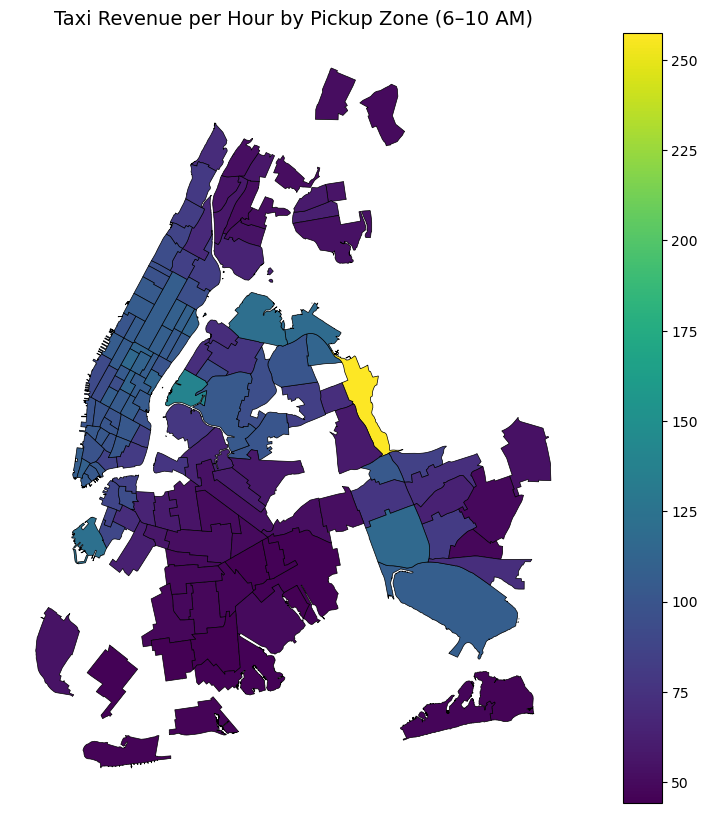

In [49]:
# plot revenue per hour on a map
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(12,10))

map_data.plot(
    column="revenue_per_hour",
    cmap="viridis",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=ax
)

ax.set_title("Taxi Revenue per Hour by Pickup Zone (6–10 AM)", fontsize=14)
ax.axis("off")

plt.show()

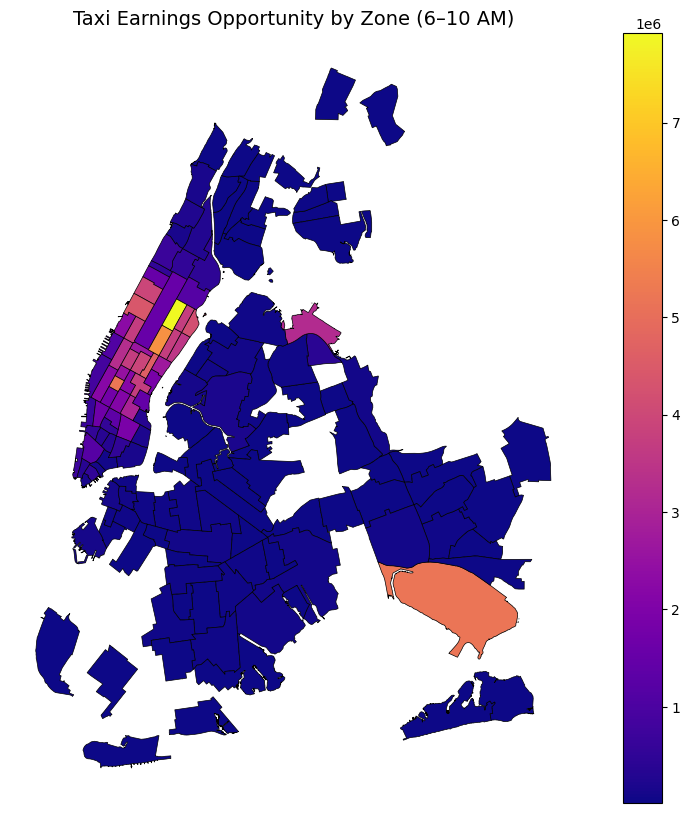

In [50]:
# now plot the earnings index instead of revenue per hour
fig, ax = plt.subplots(1, 1, figsize=(12,10))

map_data.plot(
    column="earnings_index",
    cmap="plasma",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=ax
)

ax.set_title("Taxi Earnings Opportunity by Zone (6–10 AM)", fontsize=14)
ax.axis("off")

plt.show()


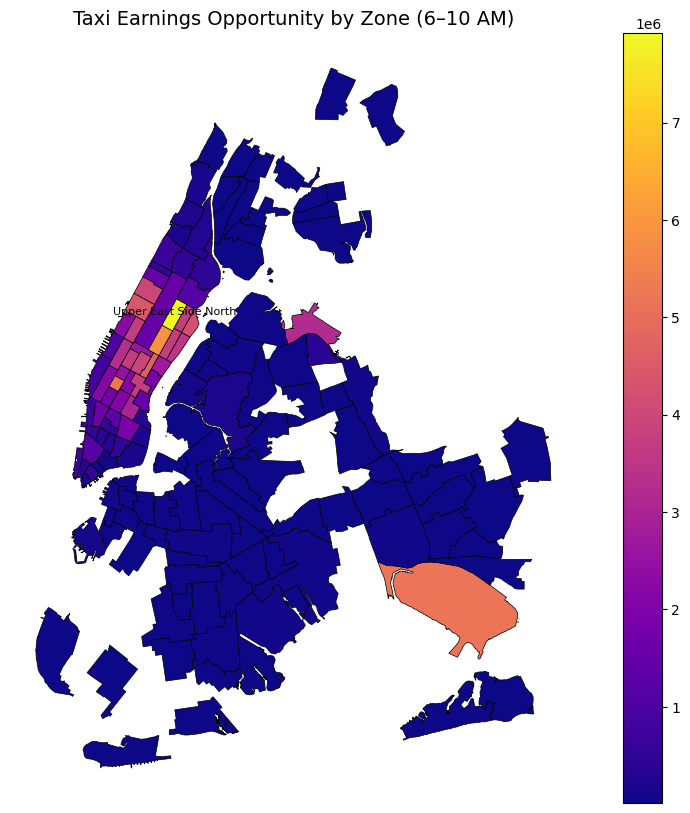

In [60]:
fig, ax = plt.subplots(1, 1, figsize=(12,10))

map_data.plot(
    column="earnings_index",
    cmap="plasma",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=ax
)

# Select top zones by earnings opportunity
top_zones = map_data.nlargest(1, "earnings_index")

# Add labels at zone centroids
for idx, row in top_zones.iterrows():
    x = row.geometry.centroid.x
    y = row.geometry.centroid.y
    
    ax.text(
        x,
        y,
        row["Zone"],   # zone name
        fontsize=8,
        ha="center"
    )

ax.set_title("Taxi Earnings Opportunity by Zone (6–10 AM)", fontsize=14)
ax.axis("off")

plt.show()

In [53]:
# measure how often drivers remain in the same zone for their next pickup 
# after dropping off a passenger
zone_transitions = con.execute(f"""
SELECT
    PULocationID,
    COUNT(*) AS trips,
    SUM(CASE WHEN PULocationID = DOLocationID THEN 1 ELSE 0 END) AS same_zone_trips,
    SUM(CASE WHEN PULocationID = DOLocationID THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS prob_same_zone
FROM read_parquet('{cleaned_dir.as_posix()}/yellow_tripdata_2024-*.parquet')
WHERE EXTRACT(hour FROM tpep_pickup_datetime) BETWEEN 6 AND 9
GROUP BY PULocationID
HAVING COUNT(*) >= 2000
ORDER BY prob_same_zone DESC
""").fetchdf()

In [54]:
zone_transitions.head(10)

,PULocationID,trips,same_zone_trips,prob_same_zone
0,264,16370,8349.0,0.510018
1,216,2883,427.0,0.148110
2,76,6581,605.0,0.091931
3,236,292000,26347.0,0.090229
4,237,217404,18983.0,0.087317
5,129,2733,223.0,0.081595
6,39,6392,513.0,0.080257
7,145,3192,249.0,0.078008
8,42,15628,1183.0,0.075697
9,166,28573,2056.0,0.071956


In [58]:
# add zone names to the transitions data
import pandas as pd

zone_lookup = pd.read_csv("../data/raw/taxi_zone_lookup.csv")

zone_transitions = zone_transitions.merge(
    zone_lookup,
    left_on="PULocationID",
    right_on="LocationID",
    how="left"
)

zone_transitions.head(10)

,PULocationID,trips,same_zone_trips,prob_same_zone,LocationID_x,Borough_x,Zone_x,service_zone_x,LocationID_y,Borough_y,Zone_y,service_zone_y
0,264,16370,8349.0,0.510018,264,Unknown,NaN,NaN,264,Unknown,NaN,NaN
1,216,2883,427.0,0.148110,216,Queens,South Ozone Park,Boro Zone,216,Queens,South Ozone Park,Boro Zone
2,76,6581,605.0,0.091931,76,Brooklyn,East New York,Boro Zone,76,Brooklyn,East New York,Boro Zone
3,236,292000,26347.0,0.090229,236,Manhattan,Upper East Side North,Yellow Zone,236,Manhattan,Upper East Side North,Yellow Zone
4,237,217404,18983.0,0.087317,237,Manhattan,Upper East Side South,Yellow Zone,237,Manhattan,Upper East Side South,Yellow Zone
5,129,2733,223.0,0.081595,129,Queens,Jackson Heights,Boro Zone,129,Queens,Jackson Heights,Boro Zone
6,39,6392,513.0,0.080257,39,Brooklyn,Canarsie,Boro Zone,39,Brooklyn,Canarsie,Boro Zone
7,145,3192,249.0,0.078008,145,Queens,Long Island City/Hunters Point,Boro Zone,145,Queens,Long Island City/Hunters Point,Boro Zone
8,42,15628,1183.0,0.075697,42,Manhattan,Central Harlem North,Boro Zone,42,Manhattan,Central Harlem North,Boro Zone
9,166,28573,2056.0,0.071956,166,Manhattan,Morningside Heights,Boro Zone,166,Manhattan,Morningside Heights,Boro Zone
